In [59]:
# =============================================================================
# 导入必要的库和模块
# =============================================================================

import numpy as np
np.random.seed(123)  # 设置随机种子以确保结果可重复

# 导入VP-STO库的轨迹规划模块
from vpsto.vpsto import VPSTO, VPSTOOptions
from vpsto.vptraj import VPTraj  # 基于通过点的随机轨迹优化器

# 导入绘图和动画库
import matplotlib.pyplot as plt    # 基础绘图功能
from matplotlib import animation   # 动画制作功能

# 导入用于处理几何形状的Shapely库
from shapely.geometry import Polygon, MultiPolygon, Point, MultiPoint, LineString

In [60]:
# Define some polygons for creating a collision environment
# 定义一些多边形以创建碰撞环境
class CollisionEnvironment():
    def __init__(self):
        self.poly_list = []
        self.poly_list.append(np.array([[0.1, 0.13], [0.23, 0.12], [0.19, 0.28], [0.1, 0.32], [0.16, 0.2]]))
        self.poly_list.append(np.array([[0.25, 0.34], [0.31, 0.35], [0.32, 0.41], [0.27, 0.44], [0.23, 0.4]]))
        self.poly_list.append(np.array([[0.35, 0.12], [0.38, 0.1], [0.41, 0.11], [0.42, 0.21], [0.35, 0.24]]))
        self.multi_poly = MultiPolygon([Polygon(self.poly_list[0]), Polygon(self.poly_list[1]), Polygon(self.poly_list[2])])
        
    def getTrajDist(self, pts):
        # pts 应该是一个二维点的数组，例如 shape=(N, 2)
        # 返回路径与障碍物的交集长度，如果有碰撞则为正数，否则为0
        return self.multi_poly.intersection(LineString(pts)).length
    
    def is_collision(self, pts):
        """
        判断轨迹是否与障碍物碰撞。

        原理:
        getTrajDist(pts) 会：
          1. 用 pts 构造一条 LineString 轨迹。
          2. 计算该轨迹与 multi_poly (所有障碍物多边形的并集) 的相交部分。
          3. 返回相交几何的总长度（>0 代表有交集，即发生碰撞）。

        这里用一个很小的阈值 (1e-6) 来避免浮点误差导致的伪碰撞。
        """
        return self.getTrajDist(pts) > 1e-2

# 实例化碰撞环境
env = CollisionEnvironment()

In [61]:
# x轴最小值为0，y轴最小值为0
q_min = 0.0*np.ones(2)
# x轴最大值为0.5，y轴最大值为0.5
q_max = 0.5*np.ones(2)
""" 位置越界惩罚"""
def loss_limits(candidates):
    q = candidates['pos']
    d_min = np.maximum(np.zeros_like(q), - q + q_min)
    d_max = np.maximum(np.zeros_like(q), q - q_max)
    return np.sum(d_min > 0.0, axis=(1,2)) + np.sum(d_max > 0.0, axis=(1,2))


""" 碰撞惩罚"""
def loss_collision(candidates): 
    costs = []
    for traj in candidates['pos']:
        costs.append(env.getTrajDist(traj))
    costs = np.array(costs)
    costs += costs > 0.0
    return costs

""" 曲率惩罚"""
def loss_curvature(candidates):
    dq = candidates['vel']
    ddq = candidates['acc']
    dq_sq = np.sum(dq**2, axis=-1)
    ddq_sq = np.sum(ddq**2, axis=-1)
    dq_ddq = np.sum(dq*ddq, axis=-1) 
    return np.mean((dq_sq * ddq_sq - dq_ddq**2) / (dq_sq**3 + 1e-6), axis=-1)

""" 总损失函数 """
def loss(candidates):
    cost_curvature = loss_curvature(candidates)
    cost_collision = loss_collision(candidates)
    cost_limits = loss_limits(candidates)
    return candidates['T'] + 1e-3 * cost_curvature + 1e3 * cost_collision + 1e3 * cost_limits

In [62]:
class MPC:
  """ 初始化MPC """
  def __init__(self, ndof, q0, dq0, qT, dqT, vel_lim, acc_lim, dt_mpc,T_stop=1.0):
    ## 单步mpc所需要的参数
    self.q0 = q0
    self.dq0 = dq0
    self.qT = qT
    self.dqT = dqT
    self.vel_lim = vel_lim
    self.acc_lim = acc_lim
    self.dt_mpc = dt_mpc # mpc控制时间步长
    self.T_stop = T_stop # 如果0路点轨迹时间小于该值，则直接采用0路点轨迹
    self.ndof = ndof

    ## 实例化变量
    # 0路点优化器配置 - 修改为2路点以避免0维优化问题
    self.opts_direct = VPSTOOptions(self.ndof)
    self.opts_direct.vel_lim = vel_lim
    self.opts_direct.acc_lim = acc_lim
    self.opts_direct.N_via = 2  # 使用2个通过点以避免维度问题
    self.opts_direct.max_iter = 50  # 减少迭代次数加快速度
    self.opts_direct.pop_size = 20  # 减少种群大小
    # 直接路径优化器
    self.traj_opt_direct = VPSTO(self.opts_direct)

    # 多路点优化器配置
    self.opts = VPSTOOptions(self.ndof)
    self.opts.vel_lim = vel_lim
    self.opts.acc_lim = acc_lim
    self.opts.N_via = 5
    self.opts.max_iter = 300  # 增加最大迭代次数
    self.opts.pop_size = 50   # 增加种群大小
    self.opts.sigma_init = 1.0 # 增加初始方差
    # 多路点优化器
    self.traj_opt = VPSTO(self.opts)

    ## mpc参数
    self.opt_sigma_init = 0.5  # 多路点优化器的初始sigma
    self.qT_tolerance = 1e-2  # 终点位置误差容忍度
    self.dqT_tolerance = 1e-2  # 终点速度误差容忍度

    ## 记录变量
    self.sol_log = []  # 记录所有解
    self.sol_valid_log = [False]  # 记录所有解是否有效
    self.q_log = []  # 记录所有位置
    self.dq_log = []  # 记录所有速度
    self.ddq_log = []  # 记录所有加速度
    self.compute_time_log = []  # 记录每次优化的计算时间
    self.is_success = False # 记录mpc是否成功
    self.total_time = 0.0 # 记录mpc总时间
  
  """ 清除记录 """
  def clear_log(self):
    self.sol_log = []  # 记录所有解
    self.sol_valid_log = [False]  # 记录所有解是否有效
    self.q_log = []  # 记录所有位置
    self.dq_log = []  # 记录所有速度
    self.ddq_log = []  # 记录所有加速度
    self.compute_time_log = []  # 记录每次优化的计算时间
    self.is_success = False # 记录mpc是否成功
    self.total_time = 0.0 # 记录mpc总时间

  """ 热启动 """
  def warmStart(self):
    self.traj_opt.set_initial_guess(self.sol_log[-1].p_best)
    self.opt_sigma_init = 1.0

  """探索模式"""
  def exploreInit(self):
    self.traj_opt.set_initial_guess(None)
    self.opt_sigma_init = 2.5
     
  """ 单步MPC """
  def mpc_single(self, q, dq):
    # 记录计算时间
    import time
    start_time = time.time()

    # 确保输入参数的维度正确
    q = np.array(q).flatten()
    dq = np.array(dq).flatten()
    
    # 获取直接路径solution
    sol_direct = self.traj_opt_direct.minimize(loss=loss, q0=q, dq0=dq, qT=self.qT, dqT=self.dqT)
    t_traj_dir = np.linspace(0, sol_direct.T_best, 1000)
    pos_direct, _, _ = sol_direct.get_posvelacc(t_traj_dir)

    # 如果0路点路径有效，并且时间小于阈值，则直接采用0路点路径
    if env.is_collision(pos_direct)==False and sol_direct.T_best<=self.T_stop :
        print("Using direct 0-via-point solution.")
        self.sol_valid_log.append(True)
        self.sol_log.append(sol_direct)
    else: # 否则用多路点优化器
        if self.sol_valid_log[-1]==True:
          # 如果上次路径有效，则用上次路径初始化 warm start
          print("Using warm start from previous solution.")
          self.warmStart()
        else:
          # 否则用探索模式初始化
          print("Using explore mode for initialization.")
          self.exploreInit()
        # 求解多路点优化器
        self.sol_opt = self.traj_opt.minimize(loss=loss, q0=q, dq0=dq, qT=self.qT, dqT=self.dqT, T=None,sigma_init=self.opt_sigma_init)
        # 验证多路点路径是否有效
        t_traj = np.linspace(0, self.sol_opt.T_best, 1000)
        pos, _, _ = self.sol_opt.get_posvelacc(t_traj)
        # 记录路径是否有效
        if env.is_collision(pos)==False:
          self.sol_valid_log.append(True)
        else:
          self.sol_valid_log.append(False)
          print("\nWarning: Collision detected in the optimized trajectory!")
          print(f"Collision {env.getTrajDist(pos):.8f} in the optimized trajectory!")
        self.sol_log.append(self.sol_opt)

    # 没有有效路径
    if self.sol_valid_log[-1]==False:
      print("\nWarning: No valid solution found in this step!")
      return None,None,None # 直接返回空
    

    ## 提取下一步的控制量
    delta_t = self.dt_mpc - self.sol_log[-1].T_best
    # 假如优化时间小于dt_mpc，则直接取终点，并进行匀加速运动
    if delta_t > 0:
      pos_end, vel_end, acc_end = self.sol_log[-1].get_posvelacc(self.sol_log[-1].T_best)
      # 确保数据是一维数组
      pos_end = np.array(pos_end).flatten()
      vel_end = np.array(vel_end).flatten()
      acc_end = np.array(acc_end).flatten()
      
      ddq_next = acc_end
      dq_next = vel_end + acc_end*delta_t
      q_next = pos_end + vel_end*delta_t + 0.5*acc_end*(delta_t**2)
    # 否则取dt_mpc时刻的状态
    else:
      q_next, dq_next, ddq_next = self.sol_log[-1].get_posvelacc(self.dt_mpc)

    # 确保输出维度一致
    q_next = np.array(q_next).flatten()
    dq_next = np.array(dq_next).flatten() 
    ddq_next = np.array(ddq_next).flatten()

    # 记录计算时间
    compute_time = time.time() - start_time
    self.compute_time_log.append(compute_time)

    # 返回控制指令
    return q_next,dq_next,ddq_next
  
  """ 判断是否到达目标 """
  def is_goal_reached(self, q, dq):
    pos_err = np.linalg.norm(q - self.qT)
    vel_err = np.linalg.norm(dq - self.dqT)
    return pos_err < self.qT_tolerance and vel_err < self.dqT_tolerance
  
  """ 计算当前位置与目标位置的距离 """
  def get_maintain_dis(self):
    return np.linalg.norm(self.q_log[-1] - self.qT)
  
  """计算性能统计"""
  def get_computation_stats(self):
      stats = {
          'success': self.is_success,
          'final_distance': self.get_maintain_dis(),
          'total_time': self.total_time,
          'avg_computation_time': np.mean(self.compute_time_log) if self.compute_time_log else 0,
          'max_computation_time': np.max(self.compute_time_log) if self.compute_time_log else 0,
          # 'success_rate': self.successful_optimizations / max(1, self.total_control_calls),
      }
      return stats
  
  """打印性能统计"""
  def print_stats(self):
      stats = self.get_computation_stats()
      print("\n simulation :")
      print(f"  任务成功: {stats['success']}")
      print(f"  仿真时间: {stats['total_time']:.2f}s") 
      print(f"  平均计算时间: {stats['avg_computation_time']*1000:.2f}ms")
      print(f"  最大计算时间: {stats['max_computation_time']*1000:.2f}ms")
      # print(f"  优化成功率: {stats['success_rate']*100:.1f}%")
  
  """ MPC循环 """
  def mpc_loop(self, N_mpc):
    # 清除记录
    self.clear_log()
    # 初始化
    q = self.q0
    dq = self.dq0
    ddq = np.zeros_like(q)
    self.q_log.append(q)
    self.dq_log.append(dq)
    self.ddq_log.append(ddq)
    
    step = 0
    while step < N_mpc :
      # 间歇显示进度，显示与目标距离
      if step % 50 == 0:
        print(f"MPC step {step}: maintain distance to goal = {self.get_maintain_dis():.4f}")

      # 检查是否到达目标
      if self.is_goal_reached(q, dq):
        print(f"\nGoal reached! total steps: {step}")
        self.is_success = True
        break

      # 执行单步MPC
      q_next, dq_next, ddq_next = self.mpc_single(q, dq)
      # 如果没有有效路径，停止MPC
      if q_next is None:
        print(f"\nMPC failed to find a valid trajectory. Stopping at step {step}.")
        break
      # 更新状态
      q = q_next
      dq = dq_next  
      ddq = ddq_next
      # 记录位置、速度、加速度
      self.q_log.append(q)
      self.dq_log.append(dq)
      self.ddq_log.append(ddq)
      # 计数器加1
      step += 1

    # 循环结束后，检查是否到达目标
    if self.is_goal_reached(q, dq):
      print(f"\nGoal reached! total steps: {step}")
      self.is_success = True
    else:
      print(f"\nMPC ended after {step} steps. Final distance to goal = {self.get_maintain_dis():.4f}")
      self.is_success = False
    
    # 计算运行总时间
    self.total_time = step * self.dt_mpc

    """打印性能统计"""
    self.print_stats()
    
  """ 获取位置、速度、加速度的记录 """
  def get_pos_vel_acc_log(self):
    return np.array(self.q_log), np.array(self.dq_log), np.array(self.ddq_log)

In [ ]:
# =============================================================================
# 初始化Online VP-STO MPC控制器
# =============================================================================
dof = 2                             # 自由度
q0 = np.array([0.4, 0.3])          # 初始位置
dq0 = np.array([0.0, 0.0])         # 初始速度
qT = np.array([0.15, 0.2])          # 目标位置
dqT = np.array([0.0, 0.0])         # 目标速度
vel_lim = 0.5*np.ones(dof)        # 速度限制
acc_lim = 1.0*np.ones(dof)        # 加速度
dt_mpc = 0.05                        # mpc控制时间步长
T_mpc = 20.0                         # mpc执行最大时长

mpc = MPC(dof, q0, dq0, qT, dqT, vel_lim, acc_lim, dt_mpc,T_stop=0.9)
# =============================================================================
# 运行MPC控制器
# =============================================================================
N_mpc = int(T_mpc/dt_mpc)

# 多次运行MPC循环
mpc_loop_num = 1
pos_profile_log = []
vel_profile_log = []
acc_profile_log = []
for i in range(mpc_loop_num):
  mpc.mpc_loop(N_mpc)
  q_log, dq_log, ddq_log = mpc.get_pos_vel_acc_log()
  pos_profile_log.append(q_log)
  vel_profile_log.append(dq_log)
  acc_profile_log.append(ddq_log)



MPC step 0: maintain distance to goal = 0.2973
VP-STO finished after 50 iterations with a final loss of 1050.14955980639
Using explore mode for initialization.
VP-STO finished after 211 iterations with a final loss of 1.6961487829513748
VP-STO finished after 50 iterations with a final loss of 1050.0507730035872
Using warm start from previous solution.
VP-STO finished after 300 iterations with a final loss of 1.6237242608021547
VP-STO finished after 50 iterations with a final loss of 1049.9541637661937
Using warm start from previous solution.
VP-STO finished after 156 iterations with a final loss of 1.558995988221209
VP-STO finished after 50 iterations with a final loss of 1049.8926105022563
Using warm start from previous solution.
VP-STO finished after 270 iterations with a final loss of 1.5033759093588466
VP-STO finished after 50 iterations with a final loss of 1049.9866359741047
Using warm start from previous solution.
VP-STO finished after 204 iterations with a final loss of 1.45514

/home/kai/miniconda3/envs/vpsto/lib/python3.10/site-packages/cma/utilities/utils.py:362: UserWarning: 
        geno-pheno transformation introduced based on the
        current covariance matrix with condition 1.2e+12 -> 1.0e+00,
        injected solutions become "invalid" in this iteration (time=Sep  2 14:41:28 2025 class=CMAEvolutionStrategy method=alleviate_conditioning iteration=265)
  warnings.warn(msg + ' (time={}'.format(time.asctime()[4:]) +


VP-STO finished after 50 iterations with a final loss of 1.3071740682675992
Using warm start from previous solution.


/home/kai/miniconda3/envs/vpsto/lib/python3.10/site-packages/cma/utilities/utils.py:362: UserWarning: 
        geno-pheno transformation introduced based on the
        current covariance matrix with condition 1.0e+12 -> 1.0e+00,
        injected solutions become "invalid" in this iteration (time=Sep  2 14:41:29 2025 class=CMAEvolutionStrategy method=alleviate_conditioning iteration=240)
  warnings.warn(msg + ' (time={}'.format(time.asctime()[4:]) +


VP-STO finished after 300 iterations with a final loss of 2.025832409736092
VP-STO finished after 50 iterations with a final loss of 1.4384081816147545
Using warm start from previous solution.
VP-STO finished after 300 iterations with a final loss of 2.1589931641208575


...

VP-STO finished after 50 iterations with a final loss of 1.612068260666089
Using warm start from previous solution.
VP-STO finished after 300 iterations with a final loss of 2.2181987656981534
VP-STO finished after 50 iterations with a final loss of 1.7456271583081022
Using warm start from previous solution.
VP-STO finished after 300 iterations with a final loss of 2.1744624233823977
VP-STO finished after 46 iterations with a final loss of 1.898688924729863
Using warm start from previous solution.
VP-STO finished after 300 iterations with a final loss of 2.0985528167151233
VP-STO finished after 44 iterations with a final loss of 1.8689432389757772
Using warm start from previous solution.
VP-STO finished after 300 iterations with a final loss of 1.997240439224676
VP-STO finished after 44 iterations with a final loss of 1.8292659453166376
Using warm start from previous solution.
VP-STO finished after 300 iterations with a final loss of 1.869442012306538
VP-STO finished after 45 iteration

/home/kai/miniconda3/envs/vpsto/lib/python3.10/site-packages/cma/utilities/utils.py:362: UserWarning: 
        geno-pheno transformation introduced based on the
        current covariance matrix with condition 1.1e+12 -> 1.0e+00,
        injected solutions become "invalid" in this iteration (time=Sep  2 14:41:43 2025 class=CMAEvolutionStrategy method=alleviate_conditioning iteration=298)
  warnings.warn(msg + ' (time={}'.format(time.asctime()[4:]) +


VP-STO finished after 45 iterations with a final loss of 1.7256630833134665
Using warm start from previous solution.
VP-STO finished after 300 iterations with a final loss of 1.5422484044723757


/home/kai/miniconda3/envs/vpsto/lib/python3.10/site-packages/cma/utilities/utils.py:362: UserWarning: 
        geno-pheno transformation introduced based on the
        current covariance matrix with condition 1.0e+12 -> 1.0e+00,
        injected solutions become "invalid" in this iteration (time=Sep  2 14:41:45 2025 class=CMAEvolutionStrategy method=alleviate_conditioning iteration=289)
  warnings.warn(msg + ' (time={}'.format(time.asctime()[4:]) +


VP-STO finished after 46 iterations with a final loss of 1.6633228051099387
Using warm start from previous solution.
VP-STO finished after 184 iterations with a final loss of 1.3634331151792844
VP-STO finished after 42 iterations with a final loss of 1.5949252792200963
Using warm start from previous solution.
VP-STO finished after 238 iterations with a final loss of 1.2994150558128157
VP-STO finished after 50 iterations with a final loss of 1.5130503185620885
Using warm start from previous solution.
VP-STO finished after 153 iterations with a final loss of 1.2424055362647857
VP-STO finished after 50 iterations with a final loss of 1.4312833899596307
Using warm start from previous solution.
VP-STO finished after 169 iterations with a final loss of 1.1860370104064983
VP-STO finished after 50 iterations with a final loss of 1.3569215859365467
Using warm start from previous solution.
VP-STO finished after 137 iterations with a final loss of 1.1179819219441745
VP-STO finished after 33 itera

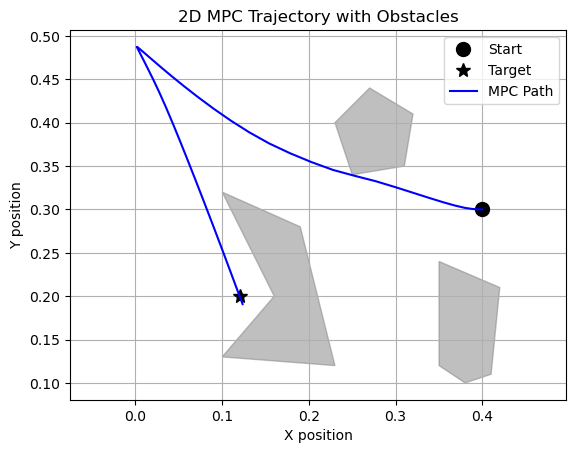

In [69]:
# =============================================================================
# 可视化环境设置
# =============================================================================
# 绘制障碍物
for poly in env.poly_list:
    polygon = plt.Polygon(poly, color='gray', alpha=0.5)
    plt.gca().add_patch(polygon)

# 绘制起点和终点
plt.plot(q0[0], q0[1], 'ko', markersize=10, label='Start')
plt.plot(qT[0], qT[1], 'k*', markersize=10, label='Target')

# 遍历获取位置记录
for i in range(mpc_loop_num):
  q_log = pos_profile_log[i]
  label = 'MPC Path' if i == 0 else None  # 只为第一个路径添加标签
  plt.plot(q_log[:, 0], q_log[:, 1], 'b-', label=label)

plt.xlim(q_min[0]-0.05, q_max[0]+0.05)
plt.ylim(q_min[1]-0.05, q_max[1]+0.05) 
plt.grid(True)
plt.legend()
plt.title('2D MPC Trajectory with Obstacles')
plt.xlabel('X position')
plt.ylabel('Y position')
plt.axis('equal')
plt.show()

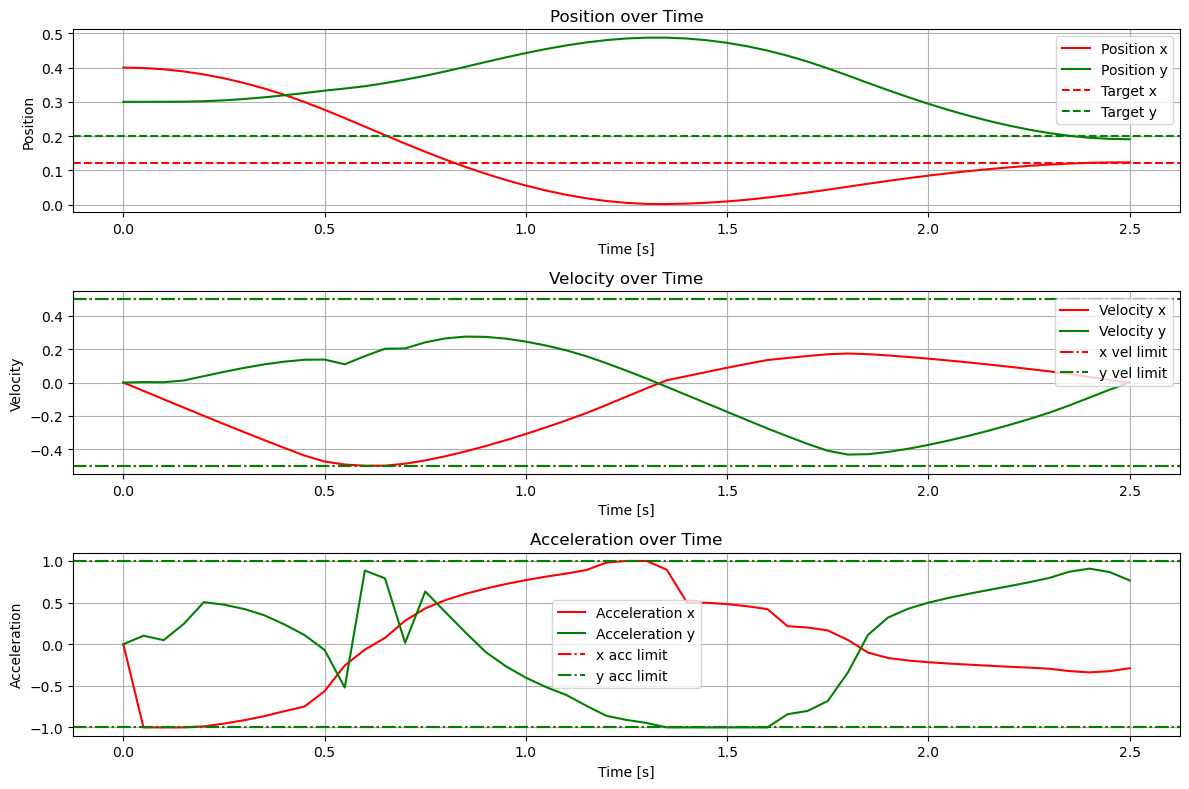

In [65]:
# =============================================================================
# MPC结果可视化与分析
# =============================================================================
# 遍历绘制位置
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
for i in range(mpc_loop_num):
  q_log = pos_profile_log[i]
  dq_log = vel_profile_log[i]
  ddq_log = acc_profile_log[i]
  time_log = np.arange(len(q_log)) * dt_mpc
  label = 'Position x' if i == 0 else None  # 只为第一个路径添加标签
  plt.plot(time_log, q_log[:, 0], 'r-', label=label)
  label = 'Position y' if i == 0 else None  # 只为第一个路径添加标签
  plt.plot(time_log, q_log[:, 1], 'g-', label=label)
plt.axhline(qT[0], color='r', linestyle='--', label='Target x')
plt.axhline(qT[1], color='g', linestyle='--', label='Target y')
plt.title('Position over Time')
plt.xlabel('Time [s]')
plt.ylabel('Position')
plt.legend()
plt.grid()

# 遍历绘制速度
for i in range(mpc_loop_num):
  q_log = pos_profile_log[i]
  dq_log = vel_profile_log[i]
  ddq_log = acc_profile_log[i]
  time_log = np.arange(len(q_log)) * dt_mpc
  plt.subplot(3, 1, 2)
  label = 'Velocity x' if i == 0 else None  # 只为第一个路径添加标签
  plt.plot(time_log, dq_log[:, 0], 'r-', label=label)
  label = 'Velocity y' if i == 0 else None  # 只为第一个路径添加标签
  plt.plot(time_log, dq_log[:, 1], 'g-', label=label)
  # plt.axhline(dqT[0], color='r', linestyle='--', label='Target vx')
  # plt.axhline(dqT[1], color='g', linestyle='--', label='Target vy')
plt.axhline(vel_lim[0], color='r', linestyle='-.', label='x vel limit')
plt.axhline(-vel_lim[0], color='r', linestyle='-.')
plt.axhline(vel_lim[1], color='g', linestyle='-.', label='y vel limit')
plt.axhline(-vel_lim[1], color='g', linestyle='-.')
plt.title('Velocity over Time')
plt.xlabel('Time [s]')
plt.ylabel('Velocity')
plt.legend()
plt.grid()
plt.subplot(3, 1, 3)

# 遍历绘制加速度
for i in range(mpc_loop_num):
  q_log = pos_profile_log[i]
  dq_log = vel_profile_log[i]
  ddq_log = acc_profile_log[i]
  time_log = np.arange(len(q_log)) * dt_mpc
  label = 'Acceleration x' if i == 0 else None  # 只为第一个路径添加标签
  plt.plot(time_log, ddq_log[:, 0], 'r-', label=label)
  label = 'Acceleration y' if i == 0 else None  # 只为第一个路径添加标签
  plt.plot(time_log, ddq_log[:, 1], 'g-', label=label)
  # plt.axhline(0, color='r', linestyle='--', label='Target ax')
  # plt.axhline(0, color='g', linestyle='--', label='Target ay')
plt.axhline(acc_lim[0], color='r', linestyle='-.', label='x acc limit')
plt.axhline(-acc_lim[0], color='r', linestyle='-.')
plt.axhline(acc_lim[1], color='g', linestyle='-.', label='y acc limit')
plt.axhline(-acc_lim[1], color='g', linestyle='-.')
plt.title('Acceleration over Time')
plt.xlabel('Time [s]')
plt.ylabel('Acceleration')  
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()